In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv

In [15]:
input_json_reviews = '../data/json/yelp_academic_dataset_review.json'
output_csv_reviews = '../data/csv/yelp_academic_dataset_review.csv'
chunk_size = 100000

def convertir_json_a_csv(input_file: str, output_file: str, chunk_size: int = 100000):
    """
    Lee un archivo JSON por bloques y lo convierte a CSV.
    
    Args:
        input_file (str): Ruta al archivo JSON original (Yelp).
        output_file (str): Ruta donde se guardará el CSV resultante.
        chunk_size (int): Número de filas a procesar por iteración.
    """
    
    reader = pd.read_json(input_file, lines=True, chunksize=chunk_size)
    
    first_chunk = True
    
    for chunk in reader:
        chunk.drop(columns=['cool', 'funny', 'useful'], errors='ignore', inplace=True)
        chunk.dropna(inplace=True)
        chunk['num_chars'] = chunk['text'].str.len()
        if first_chunk:
            # Modo 'w' (write) para crear el archivo y escribir headers
            chunk.to_csv(output_file, mode='w', index=False, encoding='utf-8')
            first_chunk = False
        else:
            # Modo 'a' (append) para añadir al final sin headers
            chunk.to_csv(output_file, mode='a', index=False, header=False, encoding='utf-8')

convertir_json_a_csv(input_json_reviews, output_csv_reviews, chunk_size)

---Ejemplos---
shape: (5, 7)
┌───────────────┬───────────────┬───────────────┬───────┬───────────────┬──────────────┬───────────┐
│ review_id     ┆ user_id       ┆ business_id   ┆ stars ┆ text          ┆ date         ┆ num_chars │
│ ---           ┆ ---           ┆ ---           ┆ ---   ┆ ---           ┆ ---          ┆ ---       │
│ str           ┆ str           ┆ str           ┆ i64   ┆ str           ┆ str          ┆ i64       │
╞═══════════════╪═══════════════╪═══════════════╪═══════╪═══════════════╪══════════════╪═══════════╡
│ KU_O5udG6zpxO ┆ mh_-eMZ6K5RLW ┆ XQfwVwDr-v0ZS ┆ 3     ┆ If you decide ┆ 2018-07-07   ┆ 513       │
│ g-VcAEodg     ┆ hZyISBhwA     ┆ 3_CbbE5Xw     ┆       ┆ to eat here,  ┆ 22:09:11     ┆           │
│               ┆               ┆               ┆       ┆ jus…          ┆              ┆           │
│ BiTunyQ73aT9W ┆ OyoGAe7OKpv6S ┆ 7ATYjTIgM3jUl ┆ 5     ┆ I've taken a  ┆ 2012-01-03   ┆ 829       │
│ BnpR9DZGw     ┆ yGZT5g77Q     ┆ t4UM3IypQ     ┆       ┆ lot 

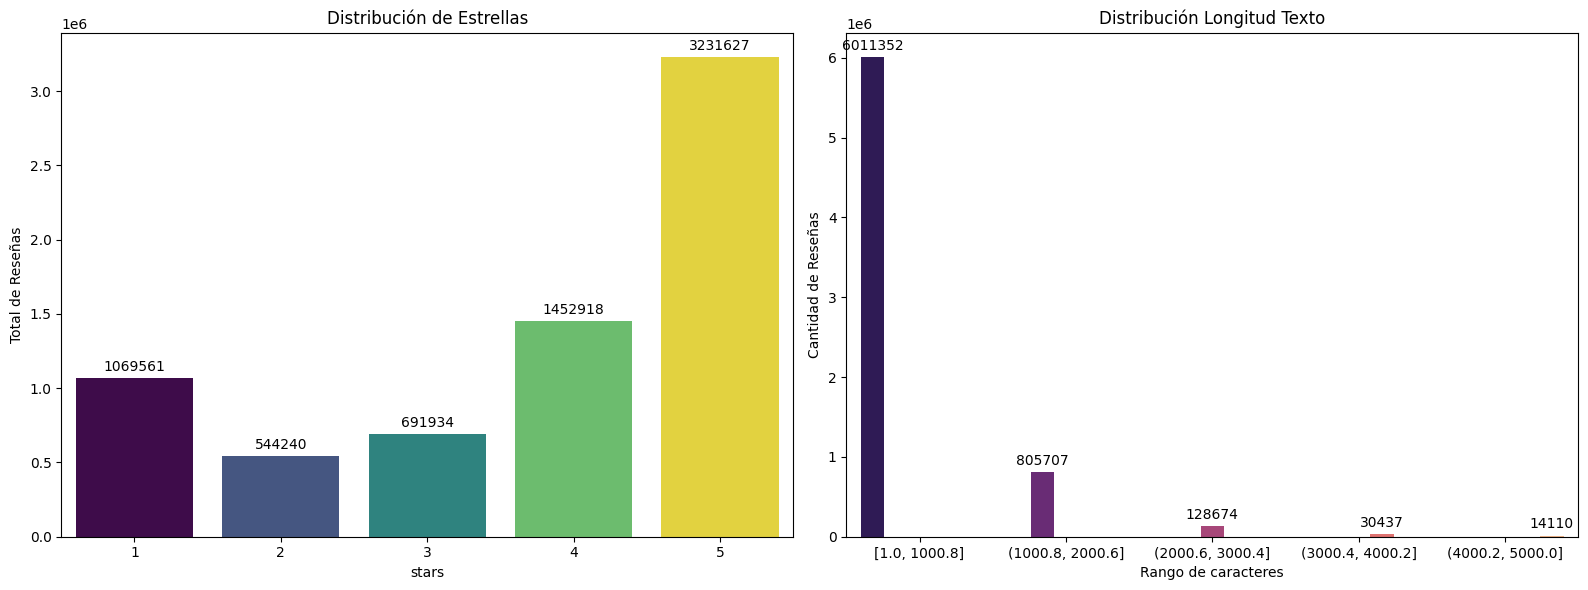

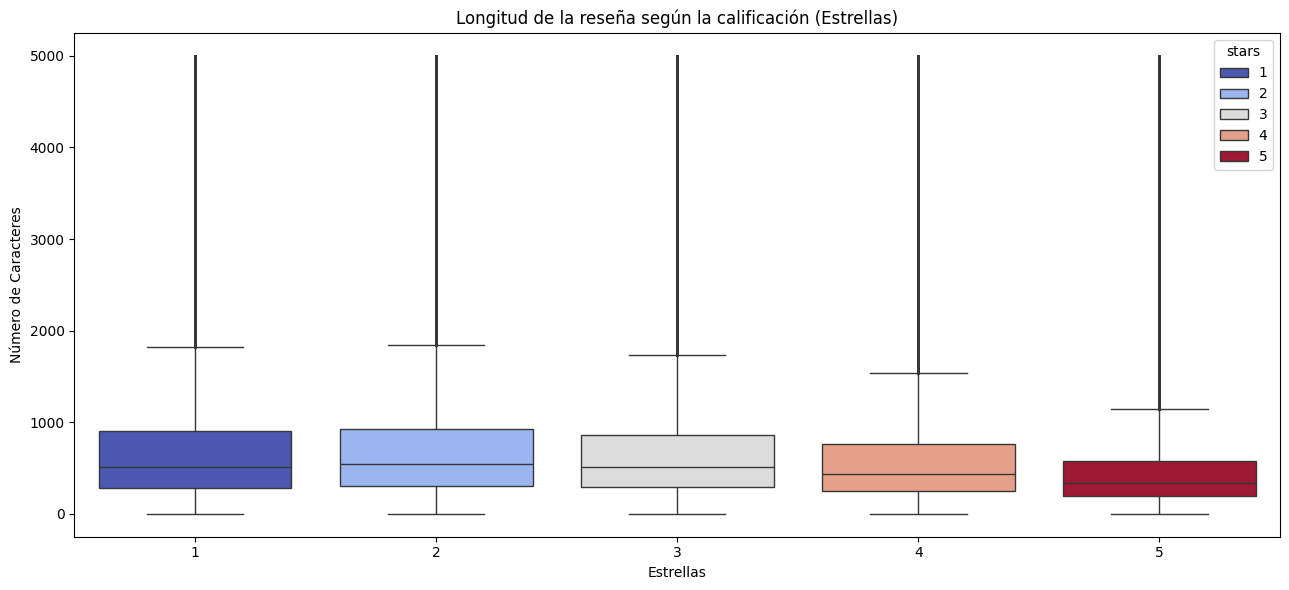

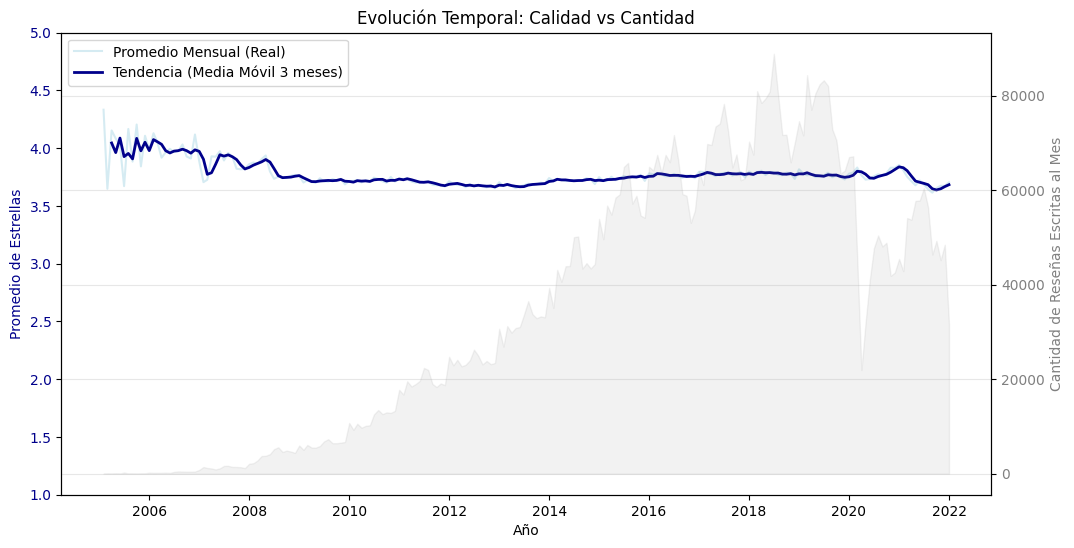

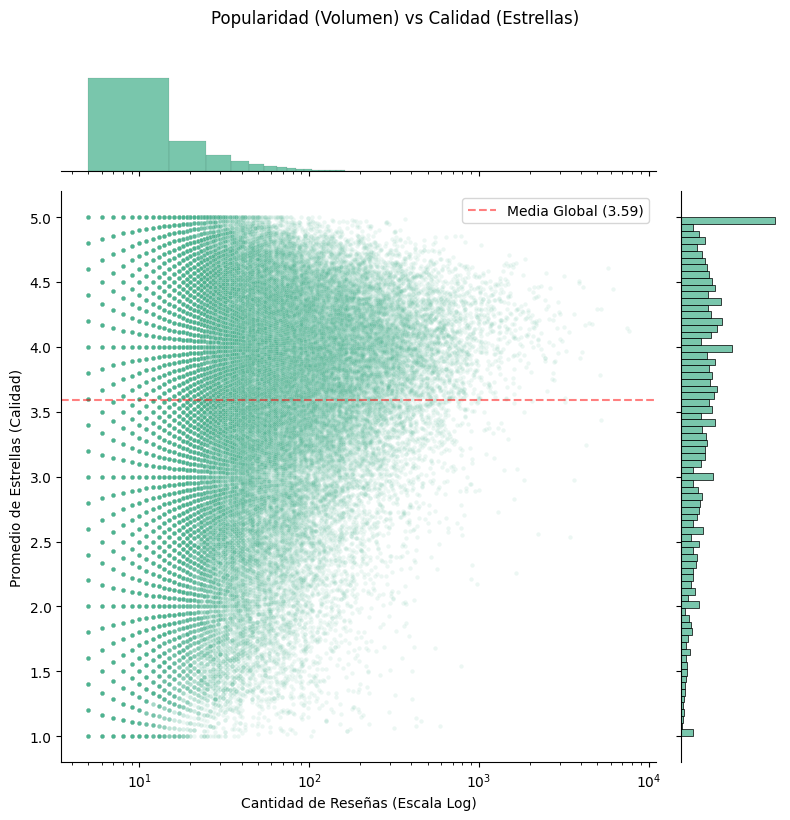

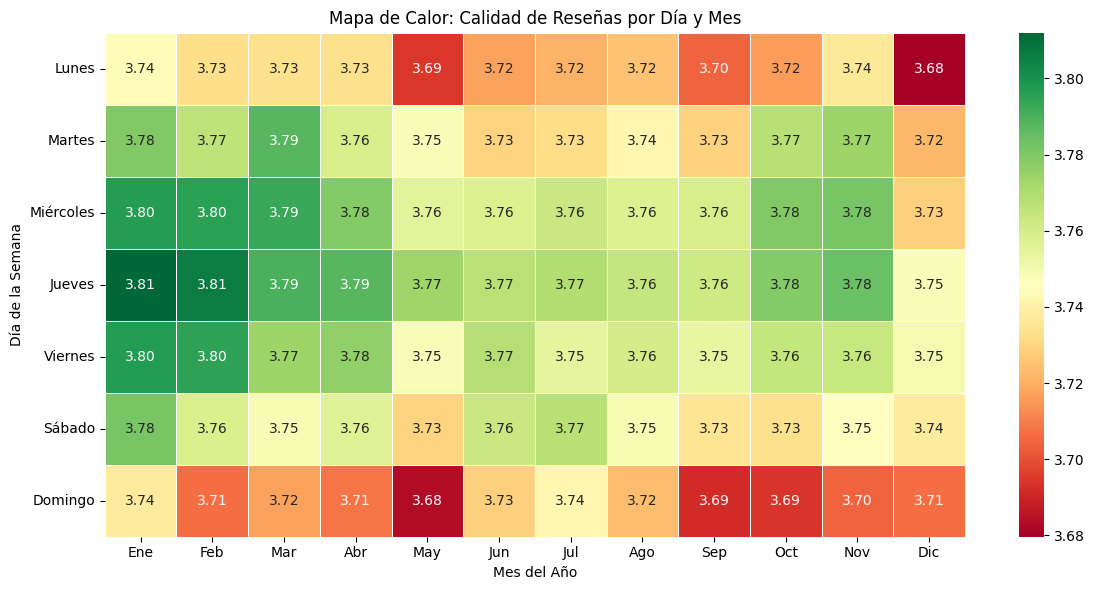

In [99]:
csv_reviews = '../data/csv/yelp_academic_dataset_review.csv'

def analisis_exploratorio(csv: str):
    """
    Realiza un EDA sobre un dataset en formato csv, realizando un sanity check, 
    la distribución de las variables y buscando patrones multivariables

    Args:
        csv (str): Ruta del fichero csv
    """
    q = pl.scan_csv(csv, ignore_errors=True)
    
    # Mostrar ejemplos
    print("---Ejemplos---")
    print(q.head(5).collect())
    
    # Contar nulos
    nulls = q.select(pl.all().null_count()).collect(engine="streaming")
    print("--- Nulos por columna ---")
    print(nulls)
    
    # Describe
    print("\n--- Estadísticas Descriptivas ---")
    numeric_cols = q.select(pl.col(pl.Int64, pl.Float64)).collect_schema().names()
    describe_df = q.select(numeric_cols).describe()
    print(describe_df)

    q = q.with_columns(
        pl.col("date").str.to_datetime(strict=False)
    )
    
    operaciones = [
        pl.len().alias("total_reviews"),
        pl.col("business_id").n_unique().alias("negocios_unicos"),
        pl.col("user_id").n_unique().alias("usuarios_unicos"),
        pl.col("date").min().alias("fecha_inicio"),
        pl.col("date").max().alias("fecha_fin")
    ]
    
    df_resultado = q.select(operaciones).collect(engine="streaming")
    
    res = df_resultado.row(0)
    print("\n--- RESULTADOS ---")
    print(f"Total de Reviews:    {res[0]:,}")
    print(f"Negocios Únicos:     {res[1]:,}")
    print(f"Usuarios Únicos:     {res[2]:,}")
    print(f"Periodo:   {res[3]} - {res[4]}")
    
    # Calculamos la duración total en días
    dias = (res[4] - res[3]).days
    print(f"Duración: {dias} días ({dias/365:.1f} años)\n")

    analisis_univariable(csv_reviews)
    analisis_multivariable(csv_reviews)
    
analisis_exploratorio(csv_reviews)

In [68]:
def analisis_univariable(csv_path: str):
    """
    Realiza un pequeño análisis estadístico sobre las variables numéricas(stars y text) para ver su distribución 
    
    Args:
        csv_path (str): Ruta al fichero csv que contiene las reviews
    """
    q = pl.scan_csv(csv_path)

    df_stars = (
        q.group_by('stars')
        .len()
        .sort('stars')
        .with_columns(
            (pl.col('len') / pl.col('len').sum() * 100).alias('percentage')
        )
        .collect()
    )
    
    series_chars = q.select('num_chars').collect().get_column('num_chars')
    
    df_hist = series_chars.hist(bin_count=5)
    
    if "category" in df_hist.columns:
        df_hist = df_hist.rename({'category': 'rango', 'count': 'total'})
    else:
        df_hist = df_hist.rename({'break_point': 'rango', 'count': 'total'})

    print("Resumen Estrellas:\n", df_stars)
    print("\nResumen Rangos Texto:\n", df_hist)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico 1: Estrellas
    sns.barplot(
        data=df_stars.to_pandas(), 
        x='stars', 
        y='len', 
        hue='stars', 
        palette='viridis', 
        ax=axes[0], 
        legend=False
    )
    axes[0].set_title("Distribución de Estrellas")
    axes[0].set_ylabel("Total de Reseñas")
    
    # Gráfico 2: Rangos Texto
    sns.barplot(
        data=df_hist.to_pandas(), 
        x='rango', 
        y='total', 
        hue='rango', 
        palette='magma', 
        ax=axes[1], 
        legend=False
    )
    
    axes[1].set_title("Distribución Longitud Texto")
    axes[1].set_xlabel("Rango de caracteres")
    axes[1].set_ylabel("Cantidad de Reseñas")

    for ax in axes:
        for container in ax.containers:
            ax.bar_label(container, fmt='%d', padding=3)

    plt.tight_layout()
    plt.show()

In [96]:
def analisis_multivariable(csv_path: str):
    """
    Realiza un análisis sobre varios conjuntos de variables para entender si hay tendencias y correlaciones entre estos

    Args:
        csv_path (str): Ruta al fichero csv que contiene las reviews
    """
    q = pl.scan_csv(csv_path)

    stars_vs_chars_boxplot(q)
    analisis_temporal_stars(q)
    analisis_popularidad_calidad_negocios(q)
    analisis_estacionalidad_reseñas(q)
    

In [70]:
def stars_vs_chars_boxplot(df: pl.DataFrame):
    """
    Realiza un boxplot de stars vs num_chars para ver la relación entre estos

    Args:
        df (DataFrame): Dataframe que contiene todas las reviews
    """
    df_stars_chars = (df.select(['stars', 'num_chars']).collect().to_pandas())
    
    plt.figure(figsize=(12, 6))
    # ¿Debería mostrar los outliers? En comparación con todas las reseñas son muy pocos pero ensucian el gráfico bastante
    sns.boxplot(data=df_stars_chars, x='stars', y='num_chars', hue='stars', palette='coolwarm', fliersize=1)
    plt.title("Longitud de la reseña según la calificación (Estrellas)")
    plt.xlabel("Estrellas")
    plt.ylabel("Número de Caracteres")
    plt.tight_layout()
    plt.show()


In [71]:
def analisis_temporal_stars(df: pl.LazyFrame):
    """
    Realiza un análisis temporal a la variable stars y al número de reseñas globales
    para ver como ha ido cambiando su comportamiento a lo largo del tiempo

    Args:
        df (LazyFrame): Dataframe que contiene todas las reviews
    """
    # Primero convertir date a datetime y truncar por mes, agrupar por esta nueva columna 
    # y añadir la media de estrellas y el número de reseñas de cada mes
    df_temporal = (df.with_columns(pl.col('date').str.to_datetime())
        .with_columns(pl.col('date').dt.truncate('1mo').alias('mes_ano'))
    .group_by('mes_ano')
    .agg([pl.col('stars').mean().alias('avg_stars'), pl.len().alias('count')])
    .sort('mes_ano').collect().to_pandas())

    df_temporal['rolling_stars'] = df_temporal['avg_stars'].rolling(window=3).mean()

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Eje Y izquierdo: Categoría de Estrellas
    sns.lineplot(data=df_temporal, x='mes_ano', y='avg_stars', ax=ax1, 
                 label='Promedio Mensual (Real)', color='lightblue', alpha=0.5)
    
    sns.lineplot(data=df_temporal, x='mes_ano', y='rolling_stars', ax=ax1, 
                 label='Tendencia (Media Móvil 3 meses)', color='darkblue', linewidth=2)

    ax1.set_ylabel('Promedio de Estrellas', color='darkblue')
    ax1.set_xlabel("Año")
    ax1.set_ylim(1, 5)
    ax1.tick_params(axis='y', labelcolor='darkblue')
    
    # Eje Y derecho: Cantidad de Reseñas
    ax2 = ax1.twinx()
    ax2.fill_between(df_temporal['mes_ano'], 0, df_temporal['count'], color='gray', alpha=0.1, label='Volumen de reseñas')
    ax2.set_ylabel('Cantidad de Reseñas Escritas al Mes', color='gray')
    ax2.set_xlabel("Año")
    ax2.tick_params(axis='y', labelcolor='gray')
    
    plt.title("Evolución Temporal: Calidad vs Cantidad")
    plt.grid(True, alpha=0.3)
    
    ax1.legend(loc='upper left')
    
    plt.show()

In [98]:
def analisis_popularidad_calidad_negocios(df: pl.LazyFrame):
    """
    Realiza un grafico de todos los negocios por el que se ve si la popularidad de un neogcio se correlaciona
    con el número de estrellas que recibe en sus reseñas

    Args:
        df (LazyFrame): Dataframe que contiene todas las reviews
    """
    df_business = (
        df.group_by("business_id")
        .agg([
            pl.len().alias("review_count"),
            pl.col("stars").mean().alias("avg_stars")
        ])
        .collect()
        .to_pandas()
    )

    grafico = sns.jointplot(
        data=df_business,
        x="review_count",
        y="avg_stars",
        kind="scatter",
        height=8,
        alpha=0.1,
        s=10,
        color="#4CB391"
    )
    
    grafico.fig.suptitle("Popularidad (Volumen) vs Calidad (Estrellas)", y=1.02)
    grafico.set_axis_labels("Cantidad de Reseñas (Popularidad)", "Promedio de Estrellas (Calidad)")
    
    # Como hay pocos negocios con miles de reseñas y muchos con pocas,
    # la escala logarítmica ayuda a ver mejor la distribución.
    grafico.ax_joint.set_xscale('log')
    grafico.ax_joint.set_xlabel("Cantidad de Reseñas (Escala Log)")
    
    # Añadimos una línea de referencia en el promedio global
    media_global = df_business["avg_stars"].mean()
    grafico.ax_joint.axhline(media_global, color='red', linestyle='--', alpha=0.5, label=f'Media Global ({media_global:.2f})')
    grafico.ax_joint.legend()
    plt.tight_layout()
    plt.show()

In [94]:
def analisis_estacionalidad_reseñas(df: pl.LazyFrame):
    """
    Realiza un mapa de calor para ver si los usuarios son más o menos 
    críticos en sus reseñas dependiendo del día de la semana y del mes

    Args:
        df (LazyFrame): Dataframe que contiene todas las reseñas
    """
    df_día_mes_estrellas = (
        df.with_columns(pl.col("date").str.to_datetime())
        .with_columns([
            pl.col("date").dt.weekday().alias("dia_num"),
            pl.col("date").dt.month().alias("mes_num")
        ])
        .group_by(["mes_num", "dia_num"])
        .agg(pl.col("stars").mean().alias("avg_stars"))
        .sort(["mes_num", "dia_num"])
        .collect()
        .to_pandas()
    )

    # Pasamos de  números a nombres los días de la semana
    mapa_dias = {1: "Lunes", 2: "Martes", 3: "Miércoles", 4: "Jueves", 5: "Viernes", 6: "Sábado", 7: "Domingo"}
    mapa_meses = {1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun", 
                  7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"}

    df_día_mes_estrellas["dia_nombre"] = df_día_mes_estrellas["dia_num"].map(mapa_dias)
    df_día_mes_estrellas["mes_nombre"] = df_día_mes_estrellas["mes_num"].map(mapa_meses)

    matriz = df_día_mes_estrellas.pivot_table(
        index="dia_nombre", 
        columns="mes_nombre", 
        values="avg_stars"
    )

    orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
    orden_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
    
    # Reindexamos la matriz para forzar el orden cronológico
    matriz = matriz.reindex(index=orden_dias, columns=orden_meses)

    plt.figure(figsize=(12, 6))
    
    sns.heatmap(matriz, cmap="RdYlGn", annot=True, fmt=".2f", linewidths=.5)

    plt.title("Calidad de Reseñas por Día y Mes")
    plt.xlabel("Mes del Año")
    plt.ylabel("Día de la Semana")
    
    plt.xticks(rotation=0) 
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()